
# Exploring `statsmodels`: Statistical Modeling in Python Post 2



In this notebook, I explore the **`statsmodels`** library, which provides
tools for **statistical modeling**, hypothesis testing, and data exploration.
I'll compare it briefly to scikit-learn and demonstrate it on a real dataset.



## 1. What is `statsmodels`?

`statsmodels` is a Python library for:

- Fitting **statistical models** (linear regression, logistic regression, time series models, etc.).  
- Performing **hypothesis tests** (t‑tests, ANOVA, etc.).  
- Producing detailed **statistical summaries** with p‑values, confidence intervals, and goodness-of-fit metrics.

How it differs from **scikit‑learn**:

- `scikit-learn` focuses on **prediction and machine learning** (pipelines, cross‑validation, etc.).  
- `statsmodels` focuses on **inference and statistics**
- `statsmodels` exposes classical statistics concepts like:
  - p‑values
  - confidence intervals
  - F‑tests
  - heteroskedasticity tests
  - diagnostic plots



### 1.1 Installation

If `statsmodels` is not already installed in the environment, you can install it with:

```bash
pip install statsmodels
```

The rest of this notebook assumes that `statsmodels`, `pandas`, `numpy`, and `matplotlib` are available.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

# Make plots a bit larger
plt.rcParams["figure.figsize"] = (6, 4)



## 2. Loading a sample dataset

`statsmodels` includes a number of built‑in datasets.  
Here I'll use the classic **mtcars** dataset (cars with various attributes).

We will try to **predict miles per gallon (`mpg`)** using car weight (`wt`) and horsepower (`hp`).


In [2]:

# Load mtcars from R datasets via statsmodels
mtcars = sm.datasets.get_rdataset("mtcars", "datasets", cache=True).data

# Make column names a little friendlier (optional)
mtcars = mtcars.rename(columns={
    "wt": "weight",
    "hp": "horsepower",
})

mtcars.head()


,mpg,cyl,disp,horsepower,drat,weight,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2



### 2.1 Basic exploration


In [3]:

mtcars.info()


<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   mpg         32 non-null     float64
 1   cyl         32 non-null     int64  
 2   disp        32 non-null     float64
 3   horsepower  32 non-null     int64  
 4   drat        32 non-null     float64
 5   weight      32 non-null     float64
 6   qsec        32 non-null     float64
 7   vs          32 non-null     int64  
 8   am          32 non-null     int64  
 9   gear        32 non-null     int64  
 10  carb        32 non-null     int64  
dtypes: float64(5), int64(6)
memory usage: 3.0+ KB


In [4]:

mtcars.describe()


,mpg,cyl,disp,horsepower,drat,weight,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000



### 2.2 Visualizing relationships

We will look at how `mpg` relates to `weight` and `horsepower`.


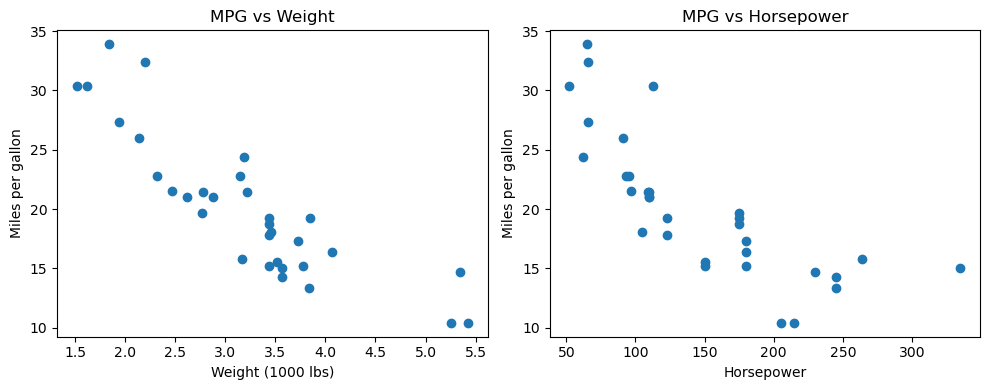

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(mtcars["weight"], mtcars["mpg"])
axes[0].set_xlabel("Weight (1000 lbs)")
axes[0].set_ylabel("Miles per gallon")
axes[0].set_title("MPG vs Weight")

axes[1].scatter(mtcars["horsepower"], mtcars["mpg"])
axes[1].set_xlabel("Horsepower")
axes[1].set_ylabel("Miles per gallon")
axes[1].set_title("MPG vs Horsepower")

plt.tight_layout()
plt.show()



## 3. Fitting a linear regression model with `statsmodels`

We will fit a **multiple linear regression** model:

\[ \text{mpg} = \beta_0 + \beta_1 \cdot \text{weight} + \beta_2 \cdot \text{horsepower} + \epsilon \]

Using the **formula API** (`statsmodels.formula.api`) we can write this as:

```python
model = smf.ols("mpg ~ weight + horsepower", data=mtcars)
result = model.fit()
```


In [6]:

# Define and fit the OLS model
model = smf.ols("mpg ~ weight + horsepower", data=mtcars)
result = model.fit()

# Show a detailed statistical summary
result.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     69.21
Date:                Tue, 09 Dec 2025   Prob (F-statistic):           9.11e-12
Time:                        18:34:07   Log-Likelihood:                -74.326
No. Observations:                  32   AIC:                             154.7
Df Residuals:                      29   BIC:                             159.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     37.2273      1.599     23.285      0.000      33.957      40.497
weight        -3.8778      0.633     -6.129      0.000      -5.172      -2.584
horsepower    -0.0318      0.009     -3.519      0.001      -0.050      -0.013
==============================================================================
Omnibus:                        5.303   Durbin-Watson:                   1.362
Prob(Omnibus):                  0.071   Jarque-Bera (JB):                4.046
Skew:                           0.855   Prob(JB):                        0.132
Kurtosis:                       3.332   Cond. No.                         588.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""


### 3.1 Interpreting the model summary

Key parts of the output to pay attention to:

- **coef**: estimated regression coefficients (intercept, weight, horsepower).
- **std err**: standard errors of the coefficients.
- **t** and **P>|t|**: t‑statistics and p‑values for the hypothesis that each coefficient is zero.
- **[0.025  0.975]**: 95% confidence intervals for the coefficients.
- **R-squared / Adj. R-squared**: proportion of variance in `mpg` explained by the model.
- **F-statistic and Prob (F-statistic)**: test whether the overall model is statistically significant.

In contrast to scikit‑learn's `LinearRegression`, `statsmodels` gives you these statistical
details **out of the box**.



## 4. Predictions and residual diagnostics

After fitting a model, we often want to:

1. Compute **predicted values**.  
2. Examine **residuals** (errors) to check model assumptions (linearity, constant variance, normality).


In [7]:

# Add predictions and residuals to the dataframe
mtcars["mpg_pred"] = result.predict(mtcars)
mtcars["residuals"] = mtcars["mpg"] - mtcars["mpg_pred"]

mtcars[["mpg", "mpg_pred", "residuals"]].head()


,mpg,mpg_pred,residuals
rownames,,,
Mazda RX4,21.0,23.572329,-2.572329
Mazda RX4 Wag,21.0,22.583483,-1.583483
Datsun 710,22.8,25.275819,-2.475819
Hornet 4 Drive,21.4,21.265020,0.134980
Hornet Sportabout,18.7,18.327267,0.372733


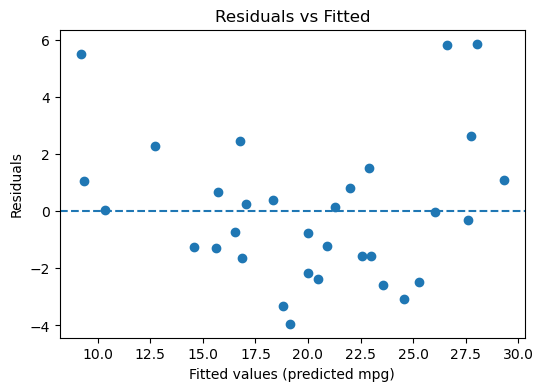

In [8]:

# Residuals vs fitted values plot
plt.scatter(mtcars["mpg_pred"], mtcars["residuals"])
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted values (predicted mpg)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()


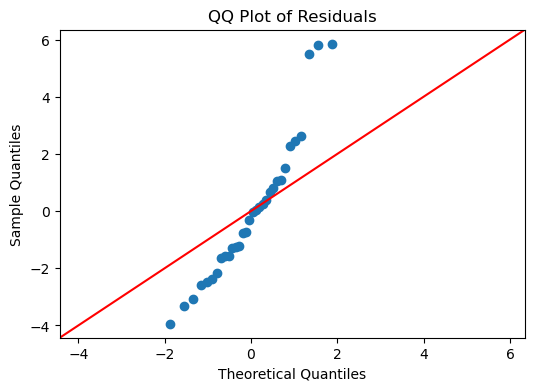

In [9]:

# QQ plot for residual normality
sm.qqplot(mtcars["residuals"], line="45")
plt.title("QQ Plot of Residuals")
plt.show()



## 5. Brief comparison with scikit-learn

Here is a quick comparison: we fit the **same model** using scikit‑learn's `LinearRegression`
and compare the coefficients.

Notice that scikit‑learn provides coefficients but **not** the rich statistical summary.


In [10]:

from sklearn.linear_model import LinearRegression

X = mtcars[["weight", "horsepower"]].values
y = mtcars["mpg"].values

linreg = LinearRegression()
linreg.fit(X, y)

print("scikit-learn coefficients:")
print("Intercept:", linreg.intercept_)
print("Weight coef:", linreg.coef_[0])
print("Horsepower coef:", linreg.coef_[1])

print("\nstatsmodels coefficients:")
print(result.params)


scikit-learn coefficients:
Intercept: 37.22727011644721
Weight coef: -3.877830742404681
Horsepower coef: -0.031772946982161016

statsmodels coefficients:
Intercept     37.227270
weight        -3.877831
horsepower    -0.031773
dtype: float64



## 6. Conclusion

In this notebook I explored the **`statsmodels`** library and demonstrated:

- How to load a built‑in dataset and explore it with pandas.  
- How to fit a **multiple linear regression** model using the **formula API**.  
- How to read the detailed **statistical summary**, including p‑values, confidence intervals,
  and goodness‑of‑fit metrics.  
- How to perform **basic diagnostic checks** using residual plots and a QQ plot.  
- How `statsmodels` compares to **scikit‑learn**, which focuses more on prediction than
  on classical statistical inference.

`statsmodels` is especially useful when you care about **explaining relationships**, 
testing hypotheses, and reporting detailed statistics in scientific or academic work.
